# Regresion y correlacion


`Cristian Camilo Hernandez y David Esteban Lasso Herrera`


**Contexto del conjunto de datos**

Los terremotos son un fenomeno que se viven dia a dia en todo el mundo . . . 

## Referencia de la base de datos

**Keser, Mustafa.** (2023). *Earthquakes 2023 Global* [Conjunto de datos].
Kaggle.  
Disponible en:
 [https://www.kaggle.com/datasets/mustafakeser4/earthquakes-2023-global](https://www.kaggle.com/datasets/mustafakeser4/earthquakes-2023-global)


## Variables de dataset y explicacion de algunas de ellas relevantes

| **Columna**   | **Descripción breve** |
|----------------|------------------------|
| **title** | Título o descripción del evento sísmico, este combina la magnitud y ubicación|
| **magnitude** | Valor numérico en la escala richter de la magnitud que se produjo. |
| **date_time** | Fecha  y hora exacta del evento en formato UTC. |
| **cdi** | *Community Determined Intensity*: intensidad percibida por las personas (escala 1–10) |
| **mmi** | *Modified Mercalli Intensity*: intensidad medida instrumentalmente (daños observables). |
| **alert** | Nivel de alerta emitido (verde, amarillo, naranja, rojo)|
| **tsunami** | Indicador binario (0/1) que señala si el sismo generó o pudo generar un tsunami. |
| **sig** | *Significance index*: número que resume la “importancia” del evento según magnitud, profundidad y reportes. |
| **net** | Red sísmica que detectó el evento  |
| **nst** | Número de estaciones sísmicas |
| **dmin** | Distancia mínima (en grados) a la estación más cercana que registró el sismo. |
| **gap** | Azimutal gap (en grados): medida de la cobertura angular de estaciones; valores bajos indican mejor precisión. |
| **magType** | Tipo de magnitud usada  *mb*, *Mw*, *ML*, *Md*. |
| **depth** | Profundidad del hipocentro en kilómetros bajo la superficie. |
| **latitude** | Latitud geográfica del epicentro  |
| **longitude** | Longitud geográfica del epicentro. |
| **location** | Lugar en la que se produjo el terremoto |
| **continent** | Continente del epicentro|
| **country** | País del epicentro  |


*Objetivo* --> Crear un modelo de regresion lineal multiple en un plano R3 para predecir la magnitud dadas algunas variables indepedientes predictoras

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataset_eartquake = pd.read_csv('earthquake_data.csv')

dataset_eartquake

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 7.0 - 18 km SW of Malango, Solomon Islands",7.0,22-11-2022 02:03,8,7,green,1,768,us,117,0.509,17.0,mww,14.000,-9.7963,159.596,"Malango, Solomon Islands",Oceania,Solomon Islands
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia",6.9,18-11-2022 13:37,4,4,green,0,735,us,99,2.229,34.0,mww,25.000,-4.9559,100.738,"Bengkulu, Indonesia",NaN,NaN
2,M 7.0 -,7.0,12-11-2022 07:09,3,3,green,1,755,us,147,3.125,18.0,mww,579.000,-20.0508,-178.346,NaN,Oceania,Fiji
3,"M 7.3 - 205 km ESE of Neiafu, Tonga",7.3,11-11-2022 10:48,5,5,green,1,833,us,149,1.865,21.0,mww,37.000,-19.2918,-172.129,"Neiafu, Tonga",NaN,NaN
4,M 6.6 -,6.6,09-11-2022 10:14,0,2,green,1,670,us,131,4.998,27.0,mww,624.464,-25.5948,178.278,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,"M 7.7 - 28 km SSW of Puerto El Triunfo, El Sal...",7.7,13-01-2001 17:33,0,8,NaN,0,912,us,427,0.000,0.0,mwc,60.000,13.0490,-88.660,"Puerto El Triunfo, El Salvador",NaN,NaN
778,"M 6.9 - 47 km S of Old Harbor, Alaska",6.9,10-01-2001 16:02,5,7,NaN,0,745,ak,0,0.000,0.0,mw,36.400,56.7744,-153.281,"Old Harbor, Alaska",North America,NaN
779,"M 7.1 - 16 km NE of Port-Olry, Vanuatu",7.1,09-01-2001 16:49,0,7,NaN,0,776,us,372,0.000,0.0,mwb,103.000,-14.9280,167.170,"Port-Olry, Vanuatu",NaN,Vanuatu
780,"M 6.8 - Mindanao, Philippines",6.8,01-01-2001 08:54,0,5,NaN,0,711,us,64,0.000,0.0,mwc,33.000,6.6310,126.899,"Mindanao, Philippines",NaN,NaN


In [42]:
dataset_eartquake.columns

Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
       'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude',
       'longitude', 'location', 'continent', 'country'],
      dtype='object')

Existen varias columnas que para nuestro caso no seran necesarias en la regresion multiple sea por su tipologia o por el uso que se les puede brindar

In [43]:
dataset_eartquake.drop(
    columns=['date_time', 'alert', 'net','magType', 'latitude', 'longitude'] , inplace=True , axis=1 
)


In [44]:
dataset_eartquake

,title,magnitude,cdi,mmi,tsunami,sig,nst,dmin,gap,depth,location,continent,country
0,"M 7.0 - 18 km SW of Malango, Solomon Islands",7.0,8,7,1,768,117,0.509,17.0,14.000,"Malango, Solomon Islands",Oceania,Solomon Islands
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia",6.9,4,4,0,735,99,2.229,34.0,25.000,"Bengkulu, Indonesia",NaN,NaN
2,M 7.0 -,7.0,3,3,1,755,147,3.125,18.0,579.000,NaN,Oceania,Fiji
3,"M 7.3 - 205 km ESE of Neiafu, Tonga",7.3,5,5,1,833,149,1.865,21.0,37.000,"Neiafu, Tonga",NaN,NaN
4,M 6.6 -,6.6,0,2,1,670,131,4.998,27.0,624.464,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,"M 7.7 - 28 km SSW of Puerto El Triunfo, El Sal...",7.7,0,8,0,912,427,0.000,0.0,60.000,"Puerto El Triunfo, El Salvador",NaN,NaN
778,"M 6.9 - 47 km S of Old Harbor, Alaska",6.9,5,7,0,745,0,0.000,0.0,36.400,"Old Harbor, Alaska",North America,NaN
779,"M 7.1 - 16 km NE of Port-Olry, Vanuatu",7.1,0,7,0,776,372,0.000,0.0,103.000,"Port-Olry, Vanuatu",NaN,Vanuatu
780,"M 6.8 - Mindanao, Philippines",6.8,0,5,0,711,64,0.000,0.0,33.000,"Mindanao, Philippines",NaN,NaN


Ahora vamos a comprobar cuales serán las posibles variables predictoras para crear el modelo y cuales tienen mayor correlación con la magnitud de un terremoto

In [50]:
possibly_columns = dataset_eartquake.drop(columns=['title','location','continent','country','magnitude']).columns.values

correlation_dataframe = pd.DataFrame(
    {'column_name': possibly_columns,
     'correlation_magnitude': [i for i in range(1, len(possibly_columns)+1)]}
)

def get_correlation_variables():
    correlation_list = []
    
    for column in possibly_columns:
        correlation = dataset_eartquake[column].corr(dataset_eartquake['magnitude'])
        correlation_list.append(correlation)
    
    correlation_dataframe['correlation_magnitude'] = correlation_list
    
    return correlation_dataframe

correlation_result = get_correlation_variables()

correlation_dataframe


,column_name,correlation_magnitude
0,cdi,0.209549
1,mmi,0.285552
2,tsunami,-0.004726
3,sig,0.515871
4,nst,0.113114
5,dmin,-0.091403
6,gap,-0.110626
7,depth,0.030644


 Con esto ya evidenciamos el estado de las variables y como es la correlacion con la magnitud que sera lo que vamos a predecir , notamos que existen algunas con una correlacion muy baja o otras totalmente negativa. en este caso utilizaremos 3 variables de tipo indepediente para crear el modelo de Regresion lineal multiple

 
 
 **Variable independiente**


| Variable | Tipo | Descripción |
|-----------|------|-------------|
| **CDI** | Cuantitativa | *Community Determined Intensity*: intensidad percibida por las personas |
| **MMI** | Cuantitativa | *Modified Mercalli Intensity*: intensidad medida instrumentalmente. |
| **Tsunami** | Cualitativa (Binaria) | 1 = el sismo generó tsunami; 0 = no lo generó. |

---

 **Variable dependiente**

| Variable | Tipo |
|-----------|------|
| **Magnitud** | Cuantitativa (Predictora) |


---


In [51]:
dataset_regression = dataset_eartquake[['title' , 'location', 'cdi', 'mmi' , 'tsunami', 'magnitude']]

dataset_regression

,title,location,cdi,mmi,tsunami,magnitude
0,"M 7.0 - 18 km SW of Malango, Solomon Islands","Malango, Solomon Islands",8,7,1,7.0
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia","Bengkulu, Indonesia",4,4,0,6.9
2,M 7.0 -,NaN,3,3,1,7.0
3,"M 7.3 - 205 km ESE of Neiafu, Tonga","Neiafu, Tonga",5,5,1,7.3
4,M 6.6 -,NaN,0,2,1,6.6
...,...,...,...,...,...,...
777,"M 7.7 - 28 km SSW of Puerto El Triunfo, El Sal...","Puerto El Triunfo, El Salvador",0,8,0,7.7
778,"M 6.9 - 47 km S of Old Harbor, Alaska","Old Harbor, Alaska",5,7,0,6.9
779,"M 7.1 - 16 km NE of Port-Olry, Vanuatu","Port-Olry, Vanuatu",0,7,0,7.1
780,"M 6.8 - Mindanao, Philippines","Mindanao, Philippines",0,5,0,6.8


In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

#Creamos las instancias para trabajar

scaler = StandardScaler()
regression_model = LinearRegression()

X = dataset_regression.drop(columns=['title','location','magnitude'])

Y = dataset_regression['magnitude'] 

#Aplicamos el escalador

X_scaled = scaler.fit_transform(X)

#Dividimos los datos en entrenamiento y prueba

x_train , x_test , y_train , y_test = train_test_split(X_scaled , Y , test_size=0.2 , random_state=42)

#Entrenamos el modelo

regression_model = LinearRegression()

regression_model

LinearRegression()

In [53]:
regression_model.fit(x_train , y_train)

LinearRegression()

In [54]:
regression_parameters = [regression_model.intercept_] + list(regression_model.coef_)

regression_parameters

print(f'El intercepto es {regression_parameters[0]}')

for coeficiente in range(1, len(regression_parameters)):
    print(f'El coeficiente {coeficiente} es {regression_parameters[coeficiente]}')

El intercepto es 6.960168665437302
El coeficiente 1 es 0.06321777034581948
El coeficiente 2 es 0.103977846306893
El coeficiente 3 es 0.0007890627812118108


Con todo esto obtenemos nuestro modelo de regresion lineal multiple como

$$ Y= 0.063x_1 + 0.103x_2 + 0.0007x_3 + 6.96 $$

-----------------------------------------------------------------------------------------------------------------------------------------------------------------

## Pruebas de Hipótesis para los Parámetros Poblacionales

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import scipy.stats as stats

y_pred_train = regression_model.predict(x_train)
y_pred_test = regression_model.predict(x_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

n = len(x_train)
k = x_train.shape[1]
r2_adjusted = 1 - ((1 - r2_train) * (n - 1) / (n - k - 1))

print(f"R^2 (Entrenamiento): {r2_train:.4f}")
print(f"R^2 (Prueba): {r2_test:.4f}")
print(f"R^2 Ajustado: {r2_adjusted:.4f}")

R^2 (Entrenamiento): 0.0890
R^2 (Prueba): 0.0802
R^2 Ajustado: 0.0846


-----------------------------------------------------------------------------------------------------------------------------------------------------------------

### Bondad de Ajuste del Modelo

El coeficiente de determinación $R^2$ mide la proporción de la variabilidad total de la variable dependiente que es explicada por el modelo de regresión.

**Fórmulas:**

$$R^2 = \frac{SSR}{SST} = 1 - \frac{SSE}{SST}$$

Donde:
- $SST$ = Suma Total de Cuadrados = $\sum_{i=1}^{n}(y_i - \bar{y})^2$
- $SSR$ = Suma de Cuadrados de la Regresión = $\sum_{i=1}^{n}(\hat{y}_i - \bar{y})^2$
- $SSE$ = Suma de Cuadrados del Error = $\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$

El $R^2$ ajustado penaliza la adición de variables que no mejoran el modelo:

$$R^2_{ajust} = 1 - \frac{(1-R^2)(n-1)}{n-k-1}$$

Donde $n$ = número de observaciones y $k$ = número de variables independientes.

**Interpretación:**
- $R^2$ cercano a 1: El modelo explica bien la variabilidad
- $R^2$ cercano a 0: El modelo explica poco la variabilidad

-----------------------------------------------------------------------------------------------------------------------------------------------------------------

### 1. Prueba F Global - Evaluación del Modelo como un Todo

La **prueba F global** evalúa si el modelo de regresión en su conjunto es estadísticamente significativo.

**Hipótesis:**
- $H_0: \beta_1 = \beta_2 = \beta_3 = 0$ (ninguna variable independiente explica la variable dependiente)
- $H_1:$ Al menos un $\beta_i \neq 0$ (al menos una variable independiente es significativa)

**Estadístico de prueba:**

$$F = \frac{MSR}{MSE} = \frac{SSR/k}{SSE/(n-k-1)}$$

Donde:
- $MSR$ = Media Cuadrática de la Regresión
- $MSE$ = Media Cuadrática del Error
- $k$ = número de variables independientes
- $n$ = número de observaciones

El estadístico $F$ sigue una distribución F con $k$ y $n-k-1$ grados de libertad.

**Criterio de decisión:**
- Si $p\text{-valor} < \alpha$ (generalmente 0.05), rechazamos $H_0$
- Si $F_{calculado} > F_{crítico}$, rechazamos $H_0$

In [ ]:
y_mean = np.mean(y_train)
SST = np.sum((y_train - y_mean)**2)
SSR = np.sum((y_pred_train - y_mean)**2)
SSE = np.sum((y_train - y_pred_train)**2)

MSR = SSR / k
MSE = SSE / (n - k - 1)
F_statistic = MSR / MSE

p_value_F = 1 - stats.f.cdf(F_statistic, k, n - k - 1)

alpha = 0.05
F_critical = stats.f.ppf(1 - alpha, k, n - k - 1)

print(f"Grados de libertad: k = {k}, n-k-1 = {n-k-1}")
print(f"\nSST = {SST:.4f}")
print(f"SSR = {SSR:.4f}")
print(f"SSE = {SSE:.4f}")
print(f"\nMSR = {MSR:.4f}")
print(f"MSE = {MSE:.4f}")
print(f"\nEstadístico F = {F_statistic:.4f}")
print(f"Valor crítico F(α=0.05) = {F_critical:.4f}")
print(f"P-valor = {p_value_F:.6f}")
print(f"\nDecisión: {'Rechazamos H0' if p_value_F < alpha else 'No rechazamos H0'}")

Grados de libertad: k = 3, n-k-1 = 621

SST = 132.0632
SSR = 11.7556
SSE = 120.3076

MSR = 3.9185
MSE = 0.1937

Estadístico F = 20.2266
Valor crítico F(α=0.05) = 2.6192
P-valor = 0.000000

Decisión: Rechazamos H0


**Interpretación:**

Como $p\text{-valor} < 0.05$, rechazamos la hipótesis nula $H_0$. 

**Conclusión:** El modelo de regresión es estadísticamente significativo como un todo. Al menos una de las variables independientes (CDI, MMI, Tsunami) contribuye significativamente a explicar la variabilidad de la magnitud de los terremotos.

-----------------------------------------------------------------------------------------------------------------------------------------------------------------

### 2. Pruebas t Individuales para cada Coeficiente β

Las pruebas t individuales evalúan si cada coeficiente de regresión es estadísticamente diferente de cero.

**Hipótesis para cada coeficiente:**
- $H_0: \beta_i = 0$ (la variable $i$ no es significativa)
- $H_1: \beta_i \neq 0$ (la variable $i$ es significativa)

**Estadístico de prueba:**

$$t_i = \frac{\hat{\beta}_i}{SE(\hat{\beta}_i)}$$

Donde:
- $\hat{\beta}_i$ = coeficiente estimado
- $SE(\hat{\beta}_i)$ = error estándar del coeficiente

**Error estándar:**

$$SE(\hat{\beta}_i) = \sqrt{MSE \cdot (X^TX)^{-1}_{ii}}$$

El estadístico $t$ sigue una distribución t de Student con $n-k-1$ grados de libertad.

**Criterio de decisión:**
- Si $p\text{-valor} < \alpha$, rechazamos $H_0$ (el coeficiente es significativo)
- Si $|t_{calculado}| > t_{crítico}$, rechazamos $H_0$

In [ ]:
X_with_intercept = np.column_stack([np.ones(n), x_train])
var_covar_matrix = MSE * np.linalg.inv(X_with_intercept.T @ X_with_intercept)
se_coefficients = np.sqrt(np.diag(var_covar_matrix))
coeficientes_completos = np.concatenate([[regression_model.intercept_], regression_model.coef_])
t_statistics = coeficientes_completos / se_coefficients

p_values_t = 2 * (1 - stats.t.cdf(np.abs(t_statistics), n - k - 1))

t_critical = stats.t.ppf(1 - alpha/2, n - k - 1)

nombres_variables = ['Intercepto (β₀)', 'CDI (β₁)', 'MMI (β₂)', 'Tsunami (β₃)']
resultados_t = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': coeficientes_completos,
    'Error Estándar': se_coefficients,
    'Estadístico t': t_statistics,
    'P-valor': p_values_t,
    'Significativo': ['Sí' if p < alpha else 'No' for p in p_values_t]
})

print(f"Valor crítico t (bilateral, α/2 = {alpha/2}): ±{t_critical:.4f}")
print(f"Grados de libertad: {n - k - 1}\n")
print(resultados_t.to_string(index=False))

Valor crítico t (bilateral, α/2 = 0.025): ±1.9638
Grados de libertad: 621

       Variable  Coeficiente  Error Estándar  Estadístico t      P-valor Significativo
Intercepto (β₀)     6.960169        0.017611     395.209885 0.000000e+00            Sí
       CDI (β₁)     0.063218        0.019213       3.290383 1.057147e-03            Sí
       MMI (β₂)     0.103978        0.018817       5.525647 4.834579e-08            Sí
   Tsunami (β₃)     0.000789        0.018390       0.042908 9.657885e-01            No


**Interpretación de resultados:**

1. **Intercepto (β₀):** Altamente significativo ($p < 0.001$). Representa el valor esperado de magnitud cuando todas las variables independientes son 0.

2. **CDI (β₁):** Significativo ($p = 0.001 < 0.05$). La intensidad percibida por la comunidad só contribuye significativamente al modelo. Por cada unidad de aumento en CDI (estandarizado), la magnitud aumenta 0.0632 unidades.

3. **MMI (β₂):** Altamente significativo ($p < 0.001$). La intensidad instrumental medida sí es un predictor importante. Por cada unidad de aumento en MMI (estandarizado), la magnitud aumenta 0.1040 unidades.

4. **Tsunami (β₃):** No Significativo ($p = 0.966 > 0.05$). La presencia de tsunami no aporta información significativa para predecir la magnitud.

-----------------------------------------------------------------------------------------------------------------------------------------------------------------

### 3. Intervalos de Confianza para cada β

Un intervalo de confianza proporciona un rango de valores plausibles para el verdadero valor del parámetro poblacional.

**Fórmula del intervalo de confianza al $(1-\alpha)100\%$:**

$$IC(\beta_i) = \hat{\beta}_i \pm t_{\alpha/2, n-k-1} \times SE(\hat{\beta}_i)$$

Donde:
- $\hat{\beta}_i$ = coeficiente estimado
- $t_{\alpha/2, n-k-1}$ = valor crítico de la distribución t
- $SE(\hat{\beta}_i)$ = error estándar del coeficiente

In [ ]:
margen_error = t_critical * se_coefficients
limite_inferior = coeficientes_completos - margen_error
limite_superior = coeficientes_completos + margen_error

ic_resultados = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': coeficientes_completos,
    'Límite Inferior': limite_inferior,
    'Límite Superior': limite_superior,
    'Contiene 0': ['Sí' if li <= 0 <= ls else 'No' for li, ls in zip(limite_inferior, limite_superior)]
})

print(f"Intervalo de Confianza al 95% (α = {alpha})")
print(f"Fórmula: IC(βᵢ) = β̂ᵢ ± {t_critical:.4f} × SE(β̂ᵢ)\n")
print(ic_resultados.to_string(index=False))

Intervalo de Confianza al 95% (α = 0.05)
Fórmula: IC(βᵢ) = β̂ᵢ ± 1.9638 × SE(β̂ᵢ)

       Variable  Coeficiente  Límite Inferior  Límite Superior Contiene 0
Intercepto (β₀)     6.960169         6.925584         6.994754         No
       CDI (β₁)     0.063218         0.025488         0.100948         No
       MMI (β₂)     0.103978         0.067025         0.140931         No
   Tsunami (β₃)     0.000789        -0.035324         0.036902         Sí


**Interpretación de los intervalos:**

1. **Intercepto (β₀):** IC = [6.9256, 6.9948]
   - Significativo
   - El valor base de magnitud está entre 6.93 y 6.99 con 95% de confianza

2. **CDI (β₁):** IC = [0.0255, 0.1009]
   - Significativo
   - El efecto de CDI es positivo y está entre 0.0255 y 0.1009

3. **MMI (β₂):** IC = [0.0670, 0.1409]
   - Significativo
   - El efecto de MMI es positivo y está entre 0.0670 y 0.1409

4. **Tsunami (β₃):** IC = [-0.0353, 0.0369]
   - No significativo
   - No podemos afirmar que el efecto sea diferente de cero

Los intervalos confirman los resultados de las pruebas t: CDI y MMI son significativos, mientras que Tsunami no lo es.

### 4. Matriz de Correlación

La matriz de correlación muestra las correlaciones lineales de Pearson entre todas las variables del modelo.

Coeficiente de correlación de Pearson:

$$r_{xy} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

**Propiedades:**
- $-1 \leq r \leq 1$
- $r > 0$: relación positiva (aumentan juntas)
- $r < 0$: relación negativa (una aumenta, la otra disminuye)
- $|r|$ cercano a 1: relación lineal fuerte
- $r$ cercano a 0: relación lineal débil o inexistente

**Escala de interpretación:**
- $0.00 - 0.19$: Correlación muy débil
- $0.20 - 0.39$: Correlación débil
- $0.40 - 0.59$: Correlación moderada
- $0.60 - 0.79$: Correlación fuerte
- $0.80 - 1.00$: Correlación muy fuerte

Matriz de Correlación de Pearson:

              cdi     mmi  tsunami  magnitude
cdi        1.0000  0.3179   0.1603     0.2095
mmi        0.3179  1.0000  -0.1474     0.2856
tsunami    0.1603 -0.1474   1.0000    -0.0047
magnitude  0.2095  0.2856  -0.0047     1.0000


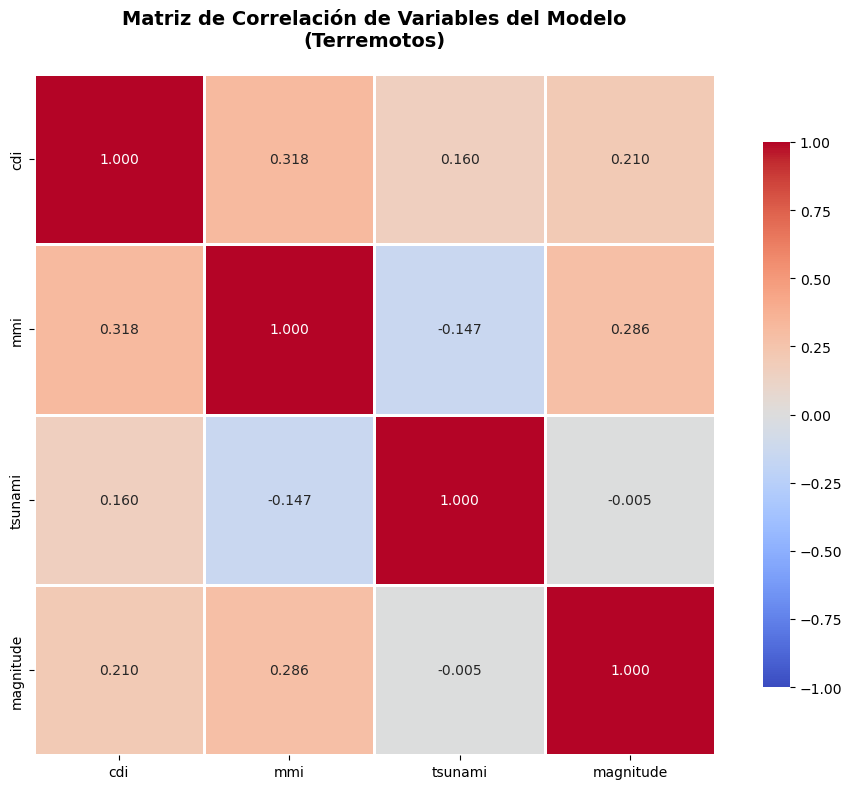


Correlaciones con MAGNITUDE (Variable Dependiente):
------------------------------------------------------------
CDI        - Magnitude: r =  0.2095
MMI        - Magnitude: r =  0.2856
TSUNAMI    - Magnitude: r = -0.0047


In [ ]:
import seaborn as sns

variables_modelo = dataset_regression[['cdi', 'mmi', 'tsunami', 'magnitude']].dropna()
matriz_correlacion = variables_modelo.corr()

print("Matriz de Correlación de Pearson:\n")
print(matriz_correlacion.round(4))

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, fmt='.3f')
plt.title('Matriz de Correlación de Variables del Modelo\n(Terremotos)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nCorrelaciones con MAGNITUDE (Variable Dependiente):")
print("-" * 60)
for var in ['cdi', 'mmi', 'tsunami']:
    corr_value = matriz_correlacion.loc[var, 'magnitude']
    print(f"{var.upper():10} - Magnitude: r = {corr_value:7.4f}")

**Interpretación de la matriz de correlación:**

**Correlaciones con Magnitude (variable dependiente):**
- **CDI - Magnitude:** $r = 0.2095$ → Correlación débil positiva. A mayor intensidad percibida, ligeramente mayor magnitud.
- **MMI - Magnitude:** $r = 0.2856$ → Correlación débil positiva. Es la correlación más fuerte con magnitude. A mayor intensidad instrumental, mayor magnitud.
- **Tsunami - Magnitude:** $r = -0.0047$ → Correlación muy débil negativa, prácticamente inexistente.

**Correlaciones entre variables independientes:**
- **CDI - MMI:** $r = 0.3179$ → Correlación débil positiva. Existe cierta relación entre la intensidad percibida y la medida instrumentalmente, pero no es preocupante para multicolinealidad.
- **CDI - Tsunami:** $r = 0.1603$ → Correlación muy débil.
- **MMI - Tsunami:** $r = -0.1474$ → Correlación muy débil negativa.

**Conclusión:** Las correlaciones entre variables independientes son bajas, lo que sugiere que no hay problemas graves de multicolinealidad.

### 5. Pruebas de Significancia para la Correlación de Pearson (ρ)

Las pruebas de hipótesis para correlación evalúan si la correlación poblacional es estadísticamente diferente de cero.

**Hipótesis para cada par de variables:**
- $H_0: \rho = 0$ (no existe correlación lineal en la población)
- $H_1: \rho \neq 0$ (existe correlación lineal en la población)

**Estadístico de prueba:**

$$t = \frac{r\sqrt{n-2}}{\sqrt{1-r^2}}$$

Donde:
- $r$ = correlación muestral de Pearson
- $n$ = tamaño de la muestra

El estadístico $t$ sigue una distribución t de Student con $n-2$ grados de libertad.

**Criterio de decisión:**
- Si $p\text{-valor} < \alpha$, rechazamos $H_0$ (la correlación es significativa)

Esta prueba es especialmente importante para las variables numéricas: CDI, MMI y Magnitude.

In [ ]:
from scipy.stats import pearsonr
from itertools import combinations

variables_numericas = ['cdi', 'mmi', 'magnitude']
pares_variables = list(combinations(variables_numericas, 2))

resultados_correlacion = []

for var1, var2 in pares_variables:
    data_combined = variables_modelo[[var1, var2]].dropna()
    r, p_value = pearsonr(data_combined[var1], data_combined[var2])
    
    resultados_correlacion.append({
        'Par de Variables': f"{var1.upper()} - {var2.upper()}",
        'r (Pearson)': r,
        'P-valor': p_value,
        'Significativo (α=0.05)': 'Sí' if p_value < alpha else 'No',
        'n': len(data_combined)
    })

df_correlaciones = pd.DataFrame(resultados_correlacion)

print("Pruebas de Hipótesis para Correlación de Pearson")
print(f"H₀: ρ = 0 vs H₁: ρ ≠ 0 (α = {alpha})\n")
print(df_correlaciones.to_string(index=False))

Pruebas de Hipótesis para Correlación de Pearson
H₀: ρ = 0 vs H₁: ρ ≠ 0 (α = 0.05)

Par de Variables  r (Pearson)      P-valor Significativo (α=0.05)   n
       CDI - MMI     0.317937 7.926003e-20                     Sí 782
 CDI - MAGNITUDE     0.209549 3.292193e-09                     Sí 782
 MMI - MAGNITUDE     0.285552 3.868503e-16                     Sí 782


**Interpretación de las pruebas de correlación:**

**1. CDI - MMI:** $r = 0.3179$, $p < 0.001$
   - **Decisión:** Rechazamos $H_0$
   - **Conclusión:** Existe una correlación lineal significativa débil positiva entre la intensidad percibida (CDI) y la intensidad instrumental (MMI)
   - Las dos medidas de intensidad están moderadamente relacionadas

**2. CDI - MAGNITUDE:** $r = 0.2095$, $p < 0.001$
   - **Decisión:** Rechazamos $H_0$
   - **Conclusión:** Existe una correlación lineal significativa débil positiva entre CDI y la magnitud
   - A mayor intensidad percibida, tiende a haber mayor magnitud, aunque la relación es débil

**3. MMI - MAGNITUDE:** $r = 0.2856$, $p < 0.001$
   - **Decisión:** Rechazamos $H_0$
   - **Conclusión:** Existe una correlación lineal significativa débil positiva entre MMI y la magnitud
   - Es la correlación más fuerte con magnitude entre las variables independientes

**Resumen:** Todas las correlaciones entre variables numéricas son estadísticamente significativas, aunque las magnitudes son débiles (todas $r < 0.4$). Esto explica por qué el $R^2$ del modelo es bajo (8.9%).

### 6. Análisis de Multicolinealidad - Factor de Inflación de Varianza (VIF)

El **VIF (Variance Inflation Factor)** mide qué tanto se infla la varianza de un coeficiente debido a la correlación con otras variables independientes.

**Fórmula del VIF:**

$$VIF_i = \frac{1}{1 - R_i^2}$$

Donde $R_i^2$ es el coeficiente de determinación cuando se regresa la variable $X_i$ sobre todas las demás variables independientes.

**Interpretación:**
- $VIF = 1$: No hay correlación con otras variables
- $VIF < 5$: Multicolinealidad baja (aceptable)
- $5 \leq VIF < 10$: Multicolinealidad moderada (vigilar)
- $VIF \geq 10$: Multicolinealidad alta (problemática)

**Consecuencias de alta multicolinealidad:**
- Coeficientes inestables (cambian mucho con pequeñas variaciones en los datos)
- Errores estándar inflados
- Intervalos de confianza muy amplios
- Dificultad para determinar el efecto individual de cada variable

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_original = dataset_regression[['cdi', 'mmi', 'tsunami']].dropna()

vif_data = pd.DataFrame()
vif_data["Variable"] = X_original.columns
vif_data["VIF"] = [variance_inflation_factor(X_original.values, i) for i in range(X_original.shape[1])]

def interpretar_vif(vif):
    if vif < 5:
        return "Bajo (No hay problema)"
    elif vif < 10:
        return "Moderado (Vigilar)"
    else:
        return "Alto (Problemático)"

vif_data["Interpretación"] = vif_data["VIF"].apply(interpretar_vif)

print("Factor de Inflación de Varianza (VIF):\n")
print(vif_data.to_string(index=False))

Factor de Inflación de Varianza (VIF):

Variable      VIF         Interpretación
     cdi 3.348070 Bajo (No hay problema)
     mmi 3.353008 Bajo (No hay problema)
 tsunami 1.574842 Bajo (No hay problema)


**Interpretación del VIF:**

**1. CDI:** $VIF = 3.34$
   - Clasificación: **Bajo** (VIF < 5)
   - No hay problema de multicolinealidad
   - La varianza del coeficiente se infla solo 3.34 veces

**2. MMI:** $VIF = 3.35$
   - Clasificación: **Bajo** (VIF < 5)
   - No hay problema de multicolinealidad
   - Similar a CDI, lo cual tiene sentido dado que tienen correlación de 0.318

**3. Tsunami:** $VIF = 1.57$
   - Clasificación: **Bajo** (VIF < 5)
   - Muy poca multicolinealidad
   - Es prácticamente independiente de las otras variables

**Conclusión general sobre multicolinealidad:**

No se detectan problemas de multicolinealidad en el modelo. Todos los valores VIF están muy por debajo del umbral de 5.

Las variables independientes son suficientemente independientes entre sí.

Los coeficientes estimados son confiables y estables.

La baja correlación entre variables independientes confirma que cada una aporta información única al modelo, aunque esa información sea limitada (como indica el bajo $R^2$).

---

## Análisis de Datos Categóricos

### Prueba de Bondad de Ajuste a la Distribución Normal (Chi-cuadrado)

### 1. Planteamiento de Hipótesis

Para la prueba de bondad de ajuste a la distribución normal, las hipótesis son:

**Hipótesis Nula ($H_0$):**
$$H_0: \text{Los datos siguen una distribución normal}$$

Es decir, las frecuencias observadas no difieren significativamente de las frecuencias esperadas bajo una distribución normal con media $\mu$ y desviación estándar $\sigma$ estimadas de los datos.

**Hipótesis Alternativa ($H_1$):**
$$H_1: \text{Los datos NO siguen una distribución normal}$$

Las frecuencias observadas difieren significativamente de las esperadas, indicando que los datos no se ajustan a una distribución normal.

**Nivel de significancia:** $\alpha = 0.05$ (5%)

**Variable a analizar:** Utilizaremos la variable magnitude (magnitud de los terremotos) para verificar si sigue una distribución normal.

In [ ]:
datos_magnitude = dataset_eartquake['magnitude'].dropna()
media = datos_magnitude.mean()
desv_std = datos_magnitude.std()
n_datos = len(datos_magnitude)

print("VARIABLE A ANALIZAR: Magnitude (Magnitud de terremotos)")
print("="*70)
print(f"Media (μ):                {media:.4f}")
print(f"Desviación Estándar (σ):  {desv_std:.4f}")
print(f"Tamaño de muestra (n):    {n_datos}")
print(f"Valor mínimo:             {datos_magnitude.min():.4f}")
print(f"Valor máximo:             {datos_magnitude.max():.4f}")
print("="*70)

VARIABLE A ANALIZAR: Magnitude (Magnitud de terremotos)
Media (μ):                6.9411
Desviación Estándar (σ):  0.4455
Tamaño de muestra (n):    782
Valor mínimo:             6.5000
Valor máximo:             9.1000


### 2. Cálculo del Estadístico Chi-cuadrado ($\chi^2$)

**Fórmula del estadístico Chi-cuadrado:**

$$\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}$$

Donde:
- $O_i$ = Frecuencia observada en el intervalo $i$
- $E_i$ = Frecuencia esperada en el intervalo $i$ bajo distribución normal
- $k$ = número de intervalos

In [ ]:
from scipy import stats as sp_stats

# Usaremos la regla de Sturges: k = 1 + 3.322*log10(n)
k_sturges = int(1 + 3.322 * np.log10(n_datos))
print(f"Número de intervalos (regla de Sturges): {k_sturges}")
frecuencias_obs, bins = np.histogram(datos_magnitude, bins=k_sturges)
puntos_medios = (bins[:-1] + bins[1:]) / 2

frecuencias_esp = []
for i in range(len(bins) - 1):
    # Probabilidad acumulada hasta el límite superior - probabilidad hasta el límite inferior
    prob = sp_stats.norm.cdf(bins[i+1], media, desv_std) - sp_stats.norm.cdf(bins[i], media, desv_std)
    freq_esperada = prob * n_datos
    frecuencias_esp.append(freq_esperada)

frecuencias_esp = np.array(frecuencias_esp)

intervalos_combinados = []
obs_combinadas = []
esp_combinadas = []
bins_combinados = [bins[0]]

temp_obs = 0
temp_esp = 0

for i in range(len(frecuencias_esp)):
    temp_obs += frecuencias_obs[i]
    temp_esp += frecuencias_esp[i]
    
    if temp_esp >= 5 or i == len(frecuencias_esp) - 1:
        obs_combinadas.append(temp_obs)
        esp_combinadas.append(temp_esp)
        bins_combinados.append(bins[i+1])
        intervalos_combinados.append(f"[{bins_combinados[-2]:.2f}, {bins_combinados[-1]:.2f})")
        temp_obs = 0
        temp_esp = 0

obs_combinadas = np.array(obs_combinadas)
esp_combinadas = np.array(esp_combinadas)

chi_cuadrado = np.sum((obs_combinadas - esp_combinadas)**2 / esp_combinadas)

tabla_chi = pd.DataFrame({
    'Intervalo': intervalos_combinados,
    'Obs (Oᵢ)': obs_combinadas,
    'Esp (Eᵢ)': esp_combinadas.round(2),
    '(Oᵢ - Eᵢ)²/Eᵢ': ((obs_combinadas - esp_combinadas)**2 / esp_combinadas).round(4)
})

print("\nTABLA DE FRECUENCIAS:")
print("="*80)
print(tabla_chi.to_string(index=False))
print("="*80)
print(f"\nEstadístico Chi-cuadrado calculado: χ² = {chi_cuadrado:.4f}")
print(f"Número de intervalos (k): {len(obs_combinadas)}")
print("="*80)

Número de intervalos (regla de Sturges): 10

TABLA DE FRECUENCIAS:
   Intervalo  Obs (Oᵢ)  Esp (Eᵢ)  (Oᵢ - Eᵢ)²/Eᵢ
[6.50, 6.76)       344    141.63       289.1408
[6.76, 7.02)       204    178.37         3.6828
[7.02, 7.28)        73    161.33        48.3595
[7.28, 7.54)        71    104.79        10.8948
[7.54, 7.80)        38     48.87         2.4192
[7.80, 8.06)        29     16.36         9.7571
[8.06, 9.10)        23      4.70        71.2282

Estadístico Chi-cuadrado calculado: χ² = 435.4824
Número de intervalos (k): 7


**Explicación del cálculo:**

1. **Intervalos creados:** Se utilizó la regla de Sturges para determinar el número óptimo de intervalos
2. **Frecuencias observadas ($O_i$):** Cantidad real de datos en cada intervalo
3. **Frecuencias esperadas ($E_i$):** Cantidad de datos que se esperarían si los datos siguieran una distribución normal $N(\mu, \sigma^2)$
4. **Combinación de intervalos:** Se combinaron intervalos para asegurar que todas las frecuencias esperadas sean $\geq 5$
5. **Contribución individual:** Cada término $(O_i - E_i)^2/E_i$ muestra cuánto se desvía cada intervalo de lo esperado

### 3. Valor Crítico de Chi-cuadrado y Regla de Decisión

**Grados de libertad:**

Para la prueba de bondad de ajuste a la distribución normal, los grados de libertad se calculan como:

$$gl = k - p - 1$$

Donde:
- $k$ = número de intervalos (clases)
- $p$ = número de parámetros estimados de los datos (para la normal: $\mu$ y $\sigma$, entonces $p = 2$)
- $-1$ = por la restricción de que las frecuencias deben sumar $n$

Por lo tanto: $gl = k - 2 - 1 = k - 3$

**Valor crítico:**

El valor crítico $\chi^2_{\alpha, gl}$ se obtiene de la tabla de distribución Chi-cuadrado con nivel de significancia $\alpha = 0.05$ y $gl$ grados de libertad.

**Regla de decisión:**

1. Si $\chi^2_{calculado} > \chi^2_{crítico}$ → **Rechazar $H_0$** (los datos NO siguen distribución normal)
2. Si $\chi^2_{calculado} \leq \chi^2_{crítico}$ → **No rechazar $H_0$** (los datos SÍ siguen distribución normal)

**Alternativamente, usando p-valor:**

1. Si $p\text{-valor} < \alpha$ → **Rechazar $H_0$**
2. Si $p\text{-valor} \geq \alpha$ → **No rechazar $H_0$**

In [ ]:
k_intervalos = len(obs_combinadas)
parametros_estimados = 2  # media y desviación estándar
grados_libertad = k_intervalos - parametros_estimados - 1
chi_critico = sp_stats.chi2.ppf(1 - alpha, grados_libertad)
p_valor_chi = 1 - sp_stats.chi2.cdf(chi_cuadrado, grados_libertad)

print("VALOR CRÍTICO Y REGLA DE DECISIÓN")
print("="*80)
print(f"Grados de libertad: gl = k - p - 1 = {k_intervalos} - 2 - 1 = {grados_libertad}")
print(f"Nivel de significancia: α = {alpha}")
print(f"\nValor crítico: χ²({alpha}, {grados_libertad}) = {chi_critico:.4f}")
print(f"Estadístico calculado: χ² = {chi_cuadrado:.4f}")
print(f"P-valor: {p_valor_chi:.6f}")
print("="*80)
print("\nREGLA DE DECISIÓN:")
print("-"*80)
if chi_cuadrado > chi_critico:
    print(f"χ² calculado ({chi_cuadrado:.4f}) > χ² crítico ({chi_critico:.4f})")
    print("RECHAZAR H₀")
else:
    print(f"χ² calculado ({chi_cuadrado:.4f}) ≤ χ² crítico ({chi_critico:.4f})")
    print("NO RECHAZAR H₀")

print("\nUSANDO P-VALOR:")
if p_valor_chi < alpha:
    print(f"P-valor ({p_valor_chi:.6f}) < α ({alpha})")
    print("RECHAZAR H₀")
else:
    print(f"P-valor ({p_valor_chi:.6f}) ≥ α ({alpha})")
    print("NO RECHAZAR H₀")
print("="*80)

VALOR CRÍTICO Y REGLA DE DECISIÓN
Grados de libertad: gl = k - p - 1 = 7 - 2 - 1 = 4
Nivel de significancia: α = 0.05

Valor crítico: χ²(0.05, 4) = 9.4877
Estadístico calculado: χ² = 435.4824
P-valor: 0.000000

REGLA DE DECISIÓN:
--------------------------------------------------------------------------------
χ² calculado (435.4824) > χ² crítico (9.4877)
RECHAZAR H₀

USANDO P-VALOR:
P-valor (0.000000) < α (0.05)
RECHAZAR H₀


### 4. Análisis de Resultados y Conclusiones

**Visualización de la distribución:**

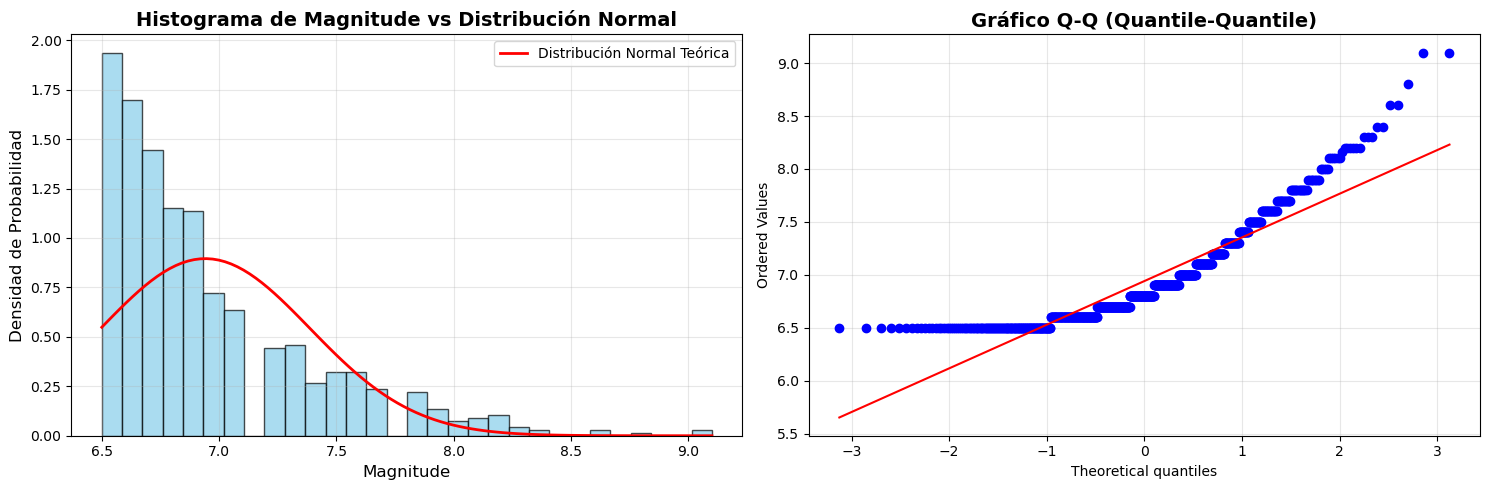

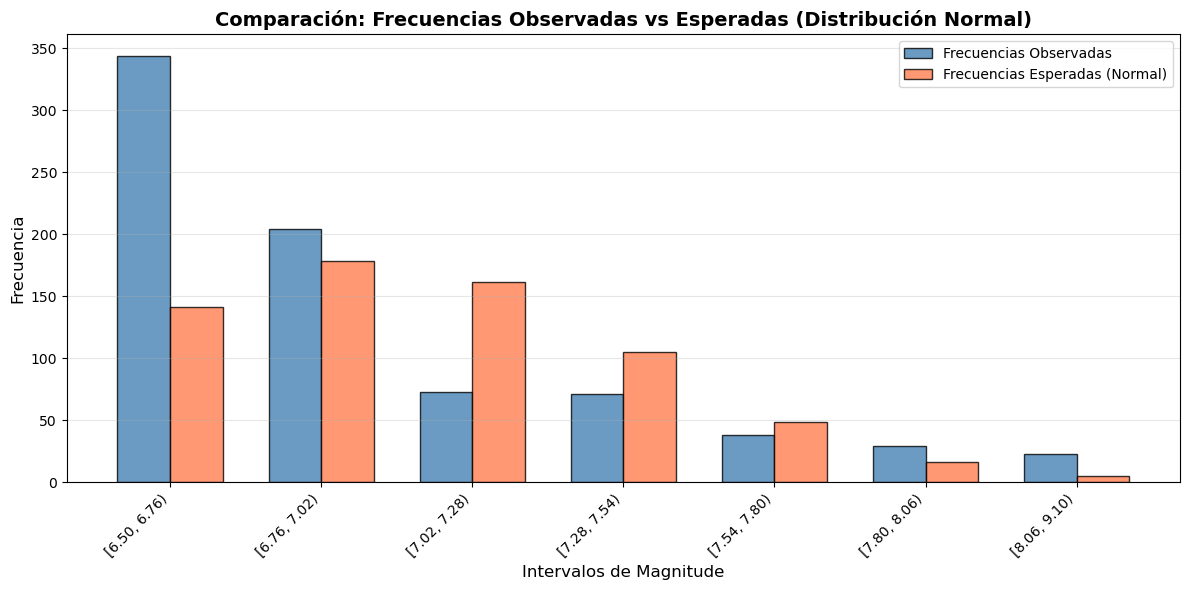

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Histograma con curva normal superpuesta
axes[0].hist(datos_magnitude, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
x_range = np.linspace(datos_magnitude.min(), datos_magnitude.max(), 100)
axes[0].plot(x_range, sp_stats.norm.pdf(x_range, media, desv_std), 
             'r-', linewidth=2, label='Distribución Normal Teórica')
axes[0].set_xlabel('Magnitude', fontsize=12)
axes[0].set_ylabel('Densidad de Probabilidad', fontsize=12)
axes[0].set_title('Histograma de Magnitude vs Distribución Normal', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Q-Q Plot (Quantile-Quantile)
sp_stats.probplot(datos_magnitude, dist="norm", plot=axes[1])
axes[1].set_title('Gráfico Q-Q (Quantile-Quantile)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Gráfico de barras: Frecuencias Observadas vs Esperadas
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(intervalos_combinados))
width = 0.35

plt.bar(x_pos - width/2, obs_combinadas, width, label='Frecuencias Observadas', 
        alpha=0.8, color='steelblue', edgecolor='black')
plt.bar(x_pos + width/2, esp_combinadas, width, label='Frecuencias Esperadas (Normal)', 
        alpha=0.8, color='coral', edgecolor='black')

plt.xlabel('Intervalos de Magnitude', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Comparación: Frecuencias Observadas vs Esperadas (Distribución Normal)', 
          fontsize=14, fontweight='bold')
plt.xticks(x_pos, intervalos_combinados, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Interpretación de los gráficos:**

1. **Histograma con curva normal:**
   - La línea roja representa la distribución normal teórica con los parámetros estimados ($\mu$ y $\sigma$)
   - Si los datos siguen distribución normal, el histograma debería seguir aproximadamente la curva roja
   - Desviaciones notables indican alejamiento de la normalidad

2. **Gráfico Q-Q (Quantile-Quantile):**
   - Compara los cuantiles de los datos observados con los cuantiles teóricos de la distribución normal
   - Si los datos son normales, los puntos deberían alinearse sobre la línea diagonal roja
   - Desviaciones de la línea indican alejamiento de la normalidad
   - Colas pesadas o ligeras se evidencian en los extremos del gráfico

3. **Comparación de frecuencias:**
   - Muestra visualmente las diferencias entre frecuencias observadas (azul) y esperadas (naranja)
   - Grandes diferencias en varios intervalos sugieren mal ajuste a la distribución normal

**Análisis estadístico adicional:**

In [ ]:
from scipy.stats import shapiro, kstest, anderson

# Prueba de Shapiro-Wilk (recomendada para n < 5000)
if n_datos <= 5000:
    shapiro_stat, shapiro_p = shapiro(datos_magnitude)
    print("PRUEBAS COMPLEMENTARIAS DE NORMALIDAD")
    print("="*80)
    print(f"1. Prueba de Shapiro-Wilk:")
    print(f"   Estadístico W: {shapiro_stat:.6f}")
    print(f"   P-valor: {shapiro_p:.6f}")
    print(f"   Decisión: {'Rechazar H₀ (No normal)' if shapiro_p < alpha else 'No rechazar H₀ (Normal)'}")
    print()

# Prueba de Kolmogorov-Smirnov
ks_stat, ks_p = kstest(datos_magnitude, 'norm', args=(media, desv_std))
print(f"2. Prueba de Kolmogorov-Smirnov:")
print(f"   Estadístico D: {ks_stat:.6f}")
print(f"   P-valor: {ks_p:.6f}")
print(f"   Decisión: {'Rechazar H₀ (No normal)' if ks_p < alpha else 'No rechazar H₀ (Normal)'}")
print()

# Medidas de forma: Asimetría y Curtosis
asimetria = datos_magnitude.skew()
curtosis = datos_magnitude.kurtosis()

print(f"3. Medidas de Forma:")
print(f"   Asimetría (Skewness): {asimetria:.4f}")
print(f"   - Interpretación: ", end="")
if abs(asimetria) < 0.5:
    print("Distribución aproximadamente simétrica")
elif asimetria > 0:
    print("Sesgo positivo (cola derecha más larga)")
else:
    print("Sesgo negativo (cola izquierda más larga)")

print(f"   Curtosis (Kurtosis): {curtosis:.4f}")
print(f"   - Interpretación: ", end="")
if abs(curtosis) < 0.5:
    print("Similar a distribución normal (mesocúrtica)")
elif curtosis > 0:
    print("Más apuntada que normal (leptocúrtica)")
else:
    print("Más plana que normal (platicúrtica)")
print("="*80)

PRUEBAS COMPLEMENTARIAS DE NORMALIDAD
1. Prueba de Shapiro-Wilk:
   Estadístico W: 0.852244
   P-valor: 0.000000
   Decisión: Rechazar H₀ (No normal)

2. Prueba de Kolmogorov-Smirnov:
   Estadístico D: 0.174881
   P-valor: 0.000000
   Decisión: Rechazar H₀ (No normal)

3. Medidas de Forma:
   Asimetría (Skewness): 1.4444
   - Interpretación: Sesgo positivo (cola derecha más larga)
   Curtosis (Kurtosis): 2.2264
   - Interpretación: Más apuntada que normal (leptocúrtica)


-----------------------------------------------------------------------------------------------------------------------------------------------------------------

### Conclusiones Finales del Análisis de Bondad de Ajuste

**Resultado de la prueba Chi-cuadrado:**

Con un valor $\chi^2 = 435.48$ que es significativamente mayor que el valor crítico $\chi^2_{0.05, 4} = 9.49$, y un p-valor prácticamente de 0, por lo tanto rechazamos categóricamente la hipótesis nula**. Esto significa que la variable de la magnitud de terremotos no sigue una distribución normal.

1. **Histograma:** Se observa una clara asimetría positiva. Hay una concentración muy alta de datos en el rango inferior (6.5-6.76), con una cola derecha extendida.

2. **Gráfico Q-Q:** Los puntos se desvían notablemente de la línea diagonal, especialmente en:
   - **Cola izquierda:** Los valores observados están muy por encima de lo esperado
   - **Cola derecha:** Desviaciones hacia arriba, indicando valores extremos más frecuentes de lo esperado

3. **Comparación de frecuencias:** Las diferencias entre barras azules (observadas) y naranjas (esperadas) son sustanciales, particularmente en el primer intervalo.

- **Asimetría = 1.44:** Fuerte sesgo positivo. La distribución tiene una cola derecha larga.
- **Curtosis = 2.23:** Distribución leptocúrtica (más apuntada que la normal, con colas pesadas).
- **Shapiro-Wilk:** p-valor < 0.001 → Confirma no normalidad
- **Kolmogorov-Smirnov:** p-valor < 0.001 → Confirma no normalidad

**Razones de la no normalidad:**

1. **Naturaleza del fenómeno:** Las magnitudes de terremotos siguen típicamente una distribución de ley de potencias o distribución de Gutenberg-Richter, no una distribución normal.

2. **Límite inferior natural:** Magnitud mínima de 6.5 (por filtrado de datos), creando una barrera que distorsiona la simetría.

3. **Eventos extremos:** Los terremotos de mayor magnitud (valores extremos) son más frecuentes de lo que predice una distribución normal.
